# Module 2 — Détection de Maladies des Plantes

Grâce à l'analyse d'images de feuilles, ce module détecte rapidement les maladies présentes, permettant des interventions précoces.

Dataset: PlantVillage

## 1) Imports et configuration

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import mobilenet_v2, resnet50
import tensorflow_datasets as tfds

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2) Chargement du dataset et paramètres

Split cohérent : **70% train / 15% validation / 15% test**.  
Le même split est utilisé pour les deux modèles.

In [22]:
# Paramètres
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
FINE_TUNE_EPOCHS = 10
LEARNING_RATE = 1e-3
FINE_TUNE_LR = 1e-5
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Charger PlantVillage avec split 70/15/15
(ds_train, ds_val, ds_test), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    with_info=True,
    as_supervised=True
)

class_names = info.features['label'].names
num_classes = info.features['label'].num_classes

print(f"[OK] Dataset PlantVillage chargé")
print(f"  Total: {info.splits['train'].num_examples} images")
print(f"  Train: {ds_train.cardinality().numpy()} | Val: {ds_val.cardinality().numpy()} | Test: {ds_test.cardinality().numpy()}")
print(f"  Classes: {num_classes}")

[OK] Dataset PlantVillage chargé
  Total: 54303 images
  Train: 38012 | Val: 8146 | Test: 8145
  Classes: 38


## 3) Exploration du dataset

Classes: 38


2026-04-16 01:12:28.411944: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,Maladie,Nombre
1,Orange___Haunglongbing_(Citrus_greening),5507
13,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
17,Soybean___healthy,5090
14,Peach___Bacterial_spot,2297
8,Tomato___Bacterial_spot,2127
2,Tomato___Late_blight,1908
9,Squash___Powdery_mildew,1835
25,Tomato___Septoria_leaf_spot,1771
7,Tomato___Spider_mites Two-spotted_spider_mite,1676
4,Apple___healthy,1645


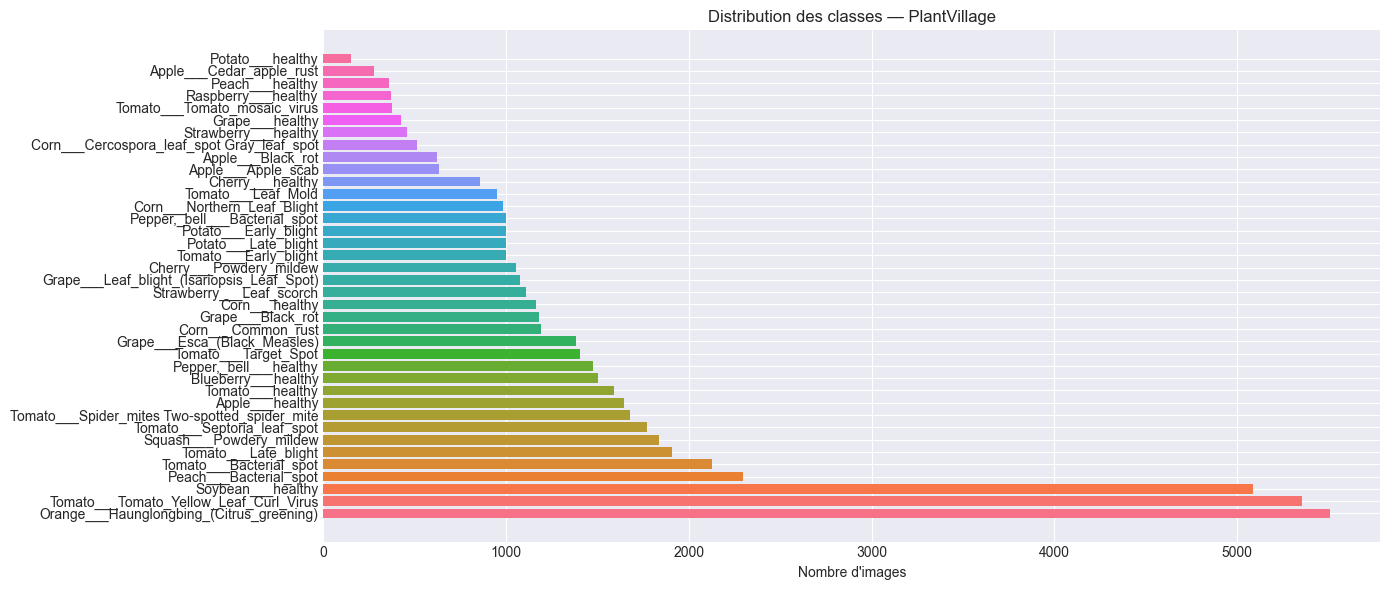

In [23]:
# Distribution des classes
label_counts = {}
for _, label in ds_train.concatenate(ds_val).concatenate(ds_test):
    label_counts[class_names[label.numpy()]] = label_counts.get(class_names[label.numpy()], 0) + 1

count_df = pd.DataFrame(
    list(label_counts.items()), columns=['Maladie', 'Nombre']
).sort_values('Nombre', ascending=False)

print(f"Classes: {num_classes}")
display(count_df)

# Graphique de distribution
plt.figure(figsize=(14, 6))
plt.barh(count_df['Maladie'], count_df['Nombre'], color=sns.color_palette("husl", len(count_df)))
plt.xlabel('Nombre d\'images')
plt.title('Distribution des classes — PlantVillage')
plt.tight_layout()
plt.show()

## 3.1) Exemples d'images

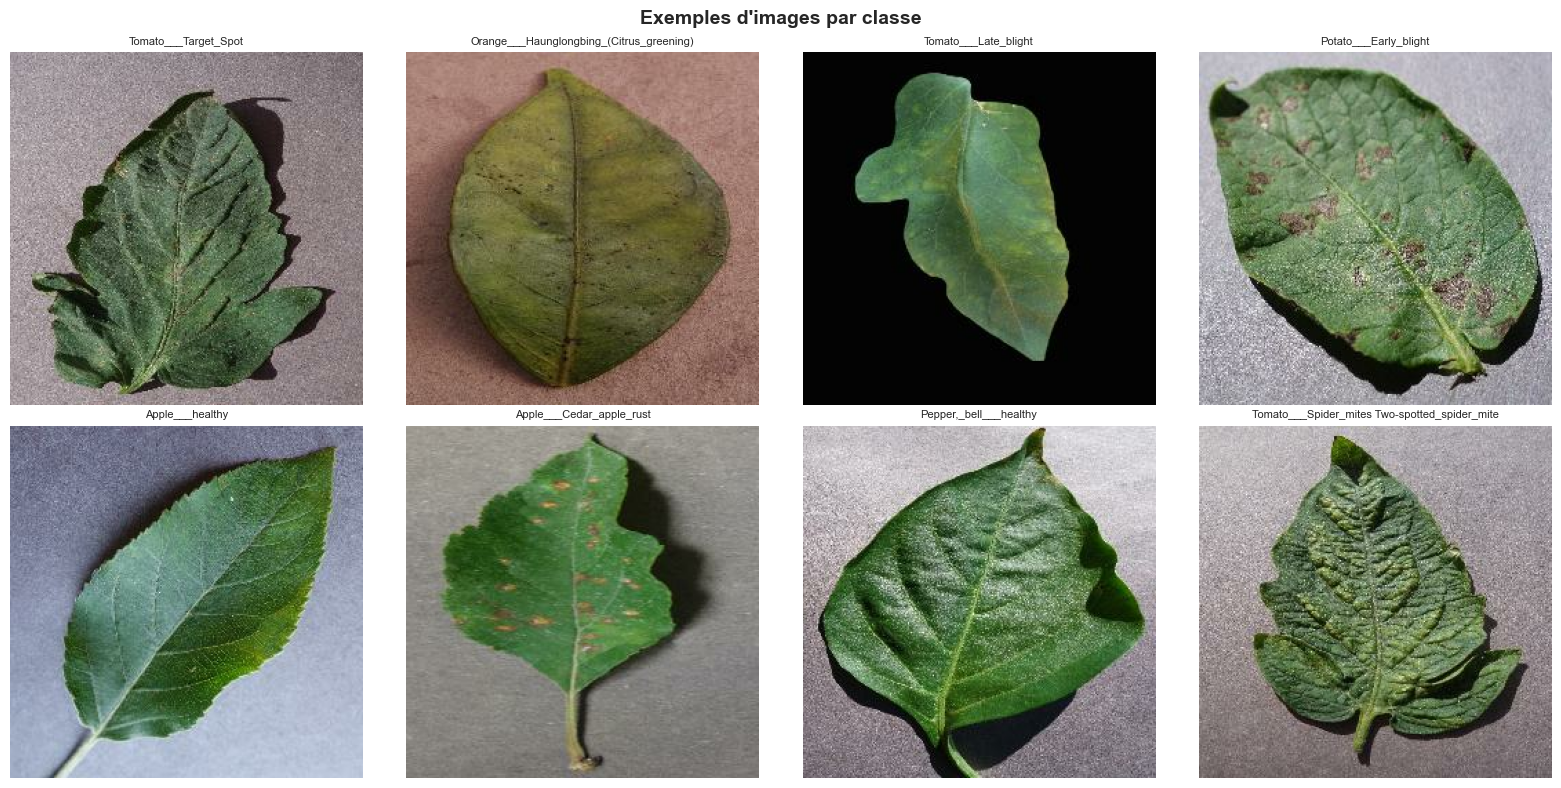

In [24]:
# Afficher quelques exemples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

seen = set()
examples = []
for image, label in ds_train:
    l = label.numpy()
    if l not in seen:
        seen.add(l)
        examples.append((image.numpy(), l))
    if len(examples) >= 8:
        break

for i, (img, lbl) in enumerate(examples):
    axes[i].imshow(img)
    axes[i].set_title(class_names[lbl], fontsize=8)
    axes[i].axis('off')

plt.suptitle("Exemples d'images par classe", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4) Prétraitement et augmentation des données

- Images redimensionnées en **224x224**
- Normalisation via `preprocess_input` spécifique à chaque modèle
- Labels en **entiers** (sparse) → `sparse_categorical_crossentropy`
- Augmentation légère sur le train uniquement (flip, rotation, zoom)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

# Augmentation sur le train uniquement
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def resize(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label

# Préparer les datasets de base
# cache() avant l'augmentation : les images redimensionnées sont mises en cache,
# l'augmentation est ré-appliquée aléatoirement à chaque époque
train_ds_base = ds_train.map(resize, num_parallel_calls=AUTOTUNE).cache()
train_ds_base = train_ds_base.shuffle(10000).map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds_base = ds_val.map(resize, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
test_ds_base = ds_test.map(resize, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

# Appliquer le preprocess_input propre à chaque modèle
# MobileNetV2
train_ds_mobile = train_ds_base.map(lambda x, y: (mobilenet_v2.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_ds_mobile = val_ds_base.map(lambda x, y: (mobilenet_v2.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
test_ds_mobile = test_ds_base.map(lambda x, y: (mobilenet_v2.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

# ResNet50
train_ds_resnet = train_ds_base.map(lambda x, y: (resnet50.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_ds_resnet = val_ds_base.map(lambda x, y: (resnet50.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
test_ds_resnet = test_ds_base.map(lambda x, y: (resnet50.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

# Calcul des poids de classes pour compenser le déséquilibre
train_labels = np.concatenate([y.numpy() for y in ds_train.map(lambda x, y: y).batch(10000)])
all_classes = np.arange(num_classes)
weights = compute_class_weight('balanced', classes=all_classes, y=train_labels)
class_weights = dict(zip(all_classes, weights))

print("[OK] Pipelines créés (avec preprocess_input spécifique)")
print(f"  Taille image: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Class weights calculés pour {len(class_weights)} classes")
print(f"  Min weight: {min(weights):.3f} | Max weight: {max(weights):.3f}")


[OK] Pipelines créés (avec preprocess_input spécifique)
  Taille image: 224x224
  Batch size: 32
  Class weights calculés pour 38 classes
  Min weight: 0.260 | Max weight: 9.437


2026-04-16 01:12:48.022894: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5) Modèle 1 — ResNet50

**Phase 1** : Transfer Learning (base gelée)  
**Phase 2** : Fine-tuning (dernières couches dégelées)

In [ ]:
# ResNet50 — Construction
base_resnet = tf.keras.applications.ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet'
)
base_resnet.trainable = False

model_resnet = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_resnet.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_checkpoint_path = os.path.join('..', 'models', 'resnet50_best.keras')
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(resnet_checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

print("[OK] ResNet50 construit (base gelée)")
model_resnet.summary()

# Phase 1 — Transfer Learning
print("\n>>> Phase 1 — ResNet50 (base gelée)...")
history_resnet_tl = model_resnet.fit(
    train_ds_resnet, validation_data=val_ds_resnet,
    epochs=EPOCHS, callbacks=[early_stop, checkpoint],
    class_weight=class_weights, verbose=1
)
print(f"[OK] Phase 1 terminée — Val Accuracy: {max(history_resnet_tl.history['val_accuracy']):.4f}")

# Phase 2 — Fine-tuning
base_resnet.trainable = True
for layer in base_resnet.layers[:-30]:
    layer.trainable = False

model_resnet.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Nouveaux callbacks pour la Phase 2 (état interne réinitialisé)
early_stop_ft = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint_ft = ModelCheckpoint(resnet_checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

print(f"\n>>> Phase 2 — ResNet50 Fine-tuning ({FINE_TUNE_EPOCHS} époques)...")
history_resnet_ft = model_resnet.fit(
    train_ds_resnet, validation_data=val_ds_resnet,
    epochs=FINE_TUNE_EPOCHS, callbacks=[early_stop_ft, checkpoint_ft],
    class_weight=class_weights, verbose=1
)

resnet_loss, resnet_acc = model_resnet.evaluate(val_ds_resnet, verbose=0)
print(f"[OK] ResNet50 — Val Accuracy: {resnet_acc:.4f} | Val Loss: {resnet_loss:.4f}")


[OK] ResNet50 construit (base gelée)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,022 (92.02 MB)

 Trainable params: 534,310 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


>>> Phase 1 — ResNet50 (base gelée)...
Epoch 1/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6406 - loss: 1.3809
Epoch 1: val_loss improved from None to 0.31210, saving model to ../../models/resnet50_best.keras

Epoch 1: finished saving model to ../../models/resnet50_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1787s 1s/step - accuracy: 0.7793 - loss: 0.7884 - val_accuracy: 0.8933 - val_loss: 0.3121
Epoch 2/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8931 - loss: 0.3325
Epoch 2: val_loss improved from 0.31210 to 0.20663, saving model to ../../models/resnet50_best.keras

Epoch 2: finished saving model to ../../models/resnet50_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1669s 1s/step - accuracy: 0.8977 - loss: 0.3160 - val_accuracy: 0.9304 - val_loss: 0.2066
Epoch 3/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9123 - loss: 0.2658
Epoch 3: val_loss did not improve from 0.20663
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1664s 1s/step - accuracy: 0.9140 - loss: 0.2

### 5.1) Courbes d'entraînement — ResNet50

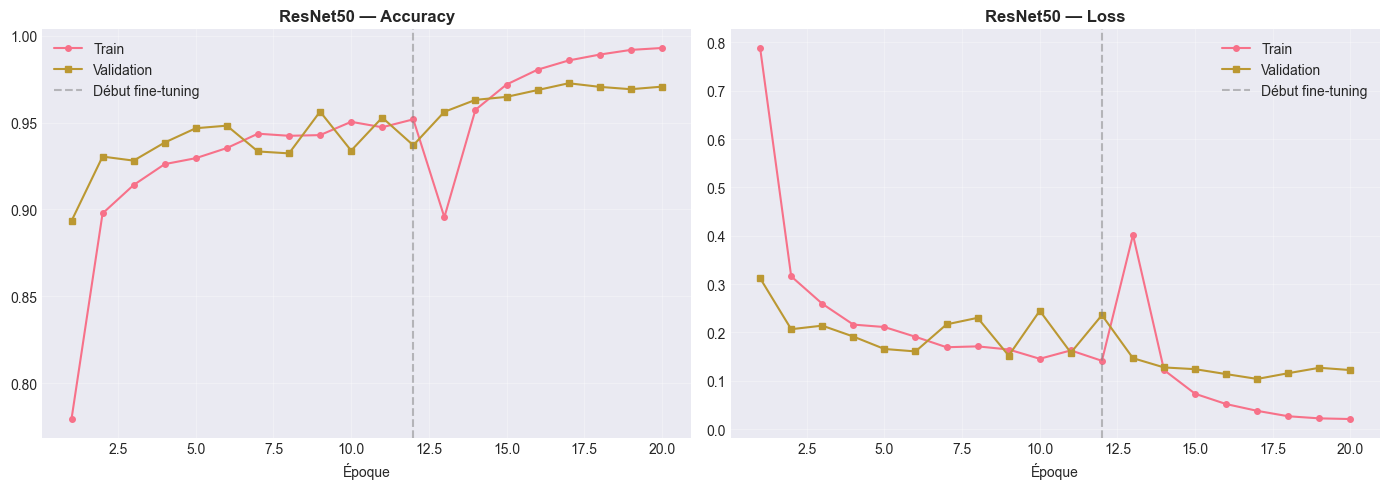

In [27]:
# Courbes ResNet50 (TL + Fine-tuning combinés)
acc_train = history_resnet_tl.history['accuracy'] + history_resnet_ft.history['accuracy']
acc_val = history_resnet_tl.history['val_accuracy'] + history_resnet_ft.history['val_accuracy']
loss_train = history_resnet_tl.history['loss'] + history_resnet_ft.history['loss']
loss_val = history_resnet_tl.history['val_loss'] + history_resnet_ft.history['val_loss']
epochs_range = range(1, len(acc_train) + 1)
cut = len(history_resnet_tl.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, acc_train, label='Train', marker='o', markersize=4)
ax1.plot(epochs_range, acc_val, label='Validation', marker='s', markersize=4)
ax1.axvline(x=cut, color='gray', linestyle='--', alpha=0.5, label='Début fine-tuning')
ax1.set_title('ResNet50 — Accuracy', fontweight='bold')
ax1.set_xlabel('Époque')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss_train, label='Train', marker='o', markersize=4)
ax2.plot(epochs_range, loss_val, label='Validation', marker='s', markersize=4)
ax2.axvline(x=cut, color='gray', linestyle='--', alpha=0.5, label='Début fine-tuning')
ax2.set_title('ResNet50 — Loss', fontweight='bold')
ax2.set_xlabel('Époque')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6) Modèle 2 — MobileNetV2

Même approche que ResNet50 : **Transfer Learning** puis **Fine-tuning**.

In [ ]:
# MobileNetV2 — Construction
base_mobile = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet'
)
base_mobile.trainable = False

model_mobile = models.Sequential([
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_mobile.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mobile_checkpoint_path = os.path.join('..', 'models', 'mobilenetv2_best.keras')
early_stop_m = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint_m = ModelCheckpoint(mobile_checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

print("[OK] MobileNetV2 construit (base gelée)")
model_mobile.summary()

# Phase 1 — Transfer Learning
print("\n>>> Phase 1 — MobileNetV2 (base gelée)...")
history_mobile_tl = model_mobile.fit(
    train_ds_mobile, validation_data=val_ds_mobile,
    epochs=EPOCHS, callbacks=[early_stop_m, checkpoint_m],
    class_weight=class_weights, verbose=1
)
print(f"[OK] Phase 1 terminée — Val Accuracy: {max(history_mobile_tl.history['val_accuracy']):.4f}")

# Phase 2 — Fine-tuning
base_mobile.trainable = True
for layer in base_mobile.layers[:-30]:
    layer.trainable = False

model_mobile.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Nouveaux callbacks pour la Phase 2 (état interne réinitialisé)
early_stop_m_ft = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint_m_ft = ModelCheckpoint(mobile_checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

print(f"\n>>> Phase 2 — MobileNetV2 Fine-tuning ({FINE_TUNE_EPOCHS} époques)...")
history_mobile_ft = model_mobile.fit(
    train_ds_mobile, validation_data=val_ds_mobile,
    epochs=FINE_TUNE_EPOCHS, callbacks=[early_stop_m_ft, checkpoint_m_ft],
    class_weight=class_weights, verbose=1
)

mobile_loss, mobile_acc = model_mobile.evaluate(val_ds_mobile, verbose=0)
print(f"[OK] MobileNetV2 — Val Accuracy: {mobile_acc:.4f} | Val Loss: {mobile_loss:.4f}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[OK] MobileNetV2 construit (base gelée)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


>>> Phase 1 — MobileNetV2 (base gelée)...
Epoch 1/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5948 - loss: 1.5288
Epoch 1: val_loss improved from None to 0.32819, saving model to ../../models/mobilenetv2_best.keras

Epoch 1: finished saving model to ../../models/mobilenetv2_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 7338s 6s/step - accuracy: 0.7319 - loss: 0.9368 - val_accuracy: 0.8945 - val_loss: 0.3282
Epoch 2/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8446 - loss: 0.4781
Epoch 2: val_loss improved from 0.32819 to 0.28705, saving model to ../../models/mobilenetv2_best.keras

Epoch 2: finished saving model to ../../models/mobilenetv2_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 702s 590ms/step - accuracy: 0.8504 - loss: 0.4574 - val_accuracy: 0.9076 - val_loss: 0.2871
Epoch 3/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.8736 - loss: 0.3794
Epoch 3: val_loss improved from 0.28705 to 0.27765, saving model to ../../models/mobilenetv2_best.k

### 6.1) Courbes d'entraînement — MobileNetV2

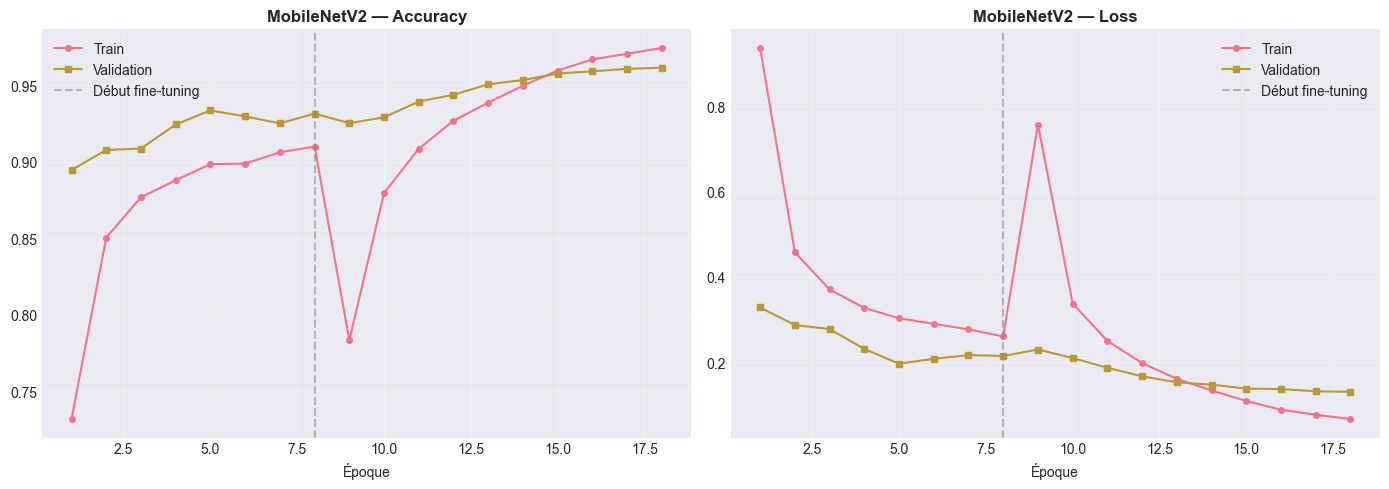

In [29]:
# Courbes MobileNetV2 (TL + Fine-tuning combinés)
acc_train_m = history_mobile_tl.history['accuracy'] + history_mobile_ft.history['accuracy']
acc_val_m = history_mobile_tl.history['val_accuracy'] + history_mobile_ft.history['val_accuracy']
loss_train_m = history_mobile_tl.history['loss'] + history_mobile_ft.history['loss']
loss_val_m = history_mobile_tl.history['val_loss'] + history_mobile_ft.history['val_loss']
epochs_range_m = range(1, len(acc_train_m) + 1)
cut_m = len(history_mobile_tl.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range_m, acc_train_m, label='Train', marker='o', markersize=4)
ax1.plot(epochs_range_m, acc_val_m, label='Validation', marker='s', markersize=4)
ax1.axvline(x=cut_m, color='gray', linestyle='--', alpha=0.5, label='Début fine-tuning')
ax1.set_title('MobileNetV2 — Accuracy', fontweight='bold')
ax1.set_xlabel('Époque')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range_m, loss_train_m, label='Train', marker='o', markersize=4)
ax2.plot(epochs_range_m, loss_val_m, label='Validation', marker='s', markersize=4)
ax2.axvline(x=cut_m, color='gray', linestyle='--', alpha=0.5, label='Début fine-tuning')
ax2.set_title('MobileNetV2 — Loss', fontweight='bold')
ax2.set_xlabel('Époque')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7) Évaluation sur le jeu de test & Comparaison

Évaluation finale des deux modèles sur le **jeu de test** (15% des données, jamais vu pendant l'entraînement).

Métriques calculées :
- **Accuracy, Precision, Recall, F1-score** (via `classification_report`)
- **Matrice de confusion** (heatmap)

In [30]:
# Évaluation ResNet50 sur le test set
y_true_r, y_pred_r = [], []
for images, labels in test_ds_resnet:
    preds = model_resnet.predict(images, verbose=0)
    y_true_r.extend(labels.numpy())
    y_pred_r.extend(np.argmax(preds, axis=1))

y_true_r = np.array(y_true_r)
y_pred_r = np.array(y_pred_r)

test_loss_r, test_acc_r = model_resnet.evaluate(test_ds_resnet, verbose=0)
f1_r = f1_score(y_true_r, y_pred_r, average='weighted')

print("=" * 60)
print("  ResNet50 — Résultats sur le jeu de TEST")
print("=" * 60)
print(f"  Test Accuracy : {test_acc_r:.4f}")
print(f"  Test Loss     : {test_loss_r:.4f}")
print(f"  F1-score      : {f1_r:.4f}")
print("\n" + classification_report(y_true_r, y_pred_r, target_names=class_names))

# Évaluation MobileNetV2 sur le test set
y_true_m, y_pred_m = [], []
for images, labels in test_ds_mobile:
    preds = model_mobile.predict(images, verbose=0)
    y_true_m.extend(labels.numpy())
    y_pred_m.extend(np.argmax(preds, axis=1))

y_true_m = np.array(y_true_m)
y_pred_m = np.array(y_pred_m)

test_loss_m, test_acc_m = model_mobile.evaluate(test_ds_mobile, verbose=0)
f1_m = f1_score(y_true_m, y_pred_m, average='weighted')

print("=" * 60)
print("  MobileNetV2 — Résultats sur le jeu de TEST")
print("=" * 60)
print(f"  Test Accuracy : {test_acc_m:.4f}")
print(f"  Test Loss     : {test_loss_m:.4f}")
print(f"  F1-score      : {f1_m:.4f}")
print("\n" + classification_report(y_true_m, y_pred_m, target_names=class_names))

2026-04-16 18:55:50.614315: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  ResNet50 — Résultats sur le jeu de TEST
  Test Accuracy : 0.9751
  Test Loss     : 0.0940
  F1-score      : 0.9750

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.98      1.00      0.99        96
                            Apple___Black_rot       0.99      1.00      1.00       107
                     Apple___Cedar_apple_rust       1.00      1.00      1.00        40
                              Apple___healthy       0.98      1.00      0.99       255
                          Blueberry___healthy       1.00      1.00      1.00       213
                             Cherry___healthy       1.00      0.99      1.00       135
                      Cherry___Powdery_mildew       1.00      0.99      0.99       147
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.88      0.92        86
                           Corn___Common_rust       1.00      1.00      1.00       185
           

2026-04-16 19:02:47.745927: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  MobileNetV2 — Résultats sur le jeu de TEST
  Test Accuracy : 0.9670
  Test Loss     : 0.1131
  F1-score      : 0.9669

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.97      0.95      0.96        96
                            Apple___Black_rot       1.00      1.00      1.00       107
                     Apple___Cedar_apple_rust       1.00      1.00      1.00        40
                              Apple___healthy       0.98      1.00      0.99       255
                          Blueberry___healthy       0.99      0.99      0.99       213
                             Cherry___healthy       0.99      0.99      0.99       135
                      Cherry___Powdery_mildew       1.00      0.99      1.00       147
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.87      0.93      0.90        86
                           Corn___Common_rust       1.00      1.00      1.00       185
        

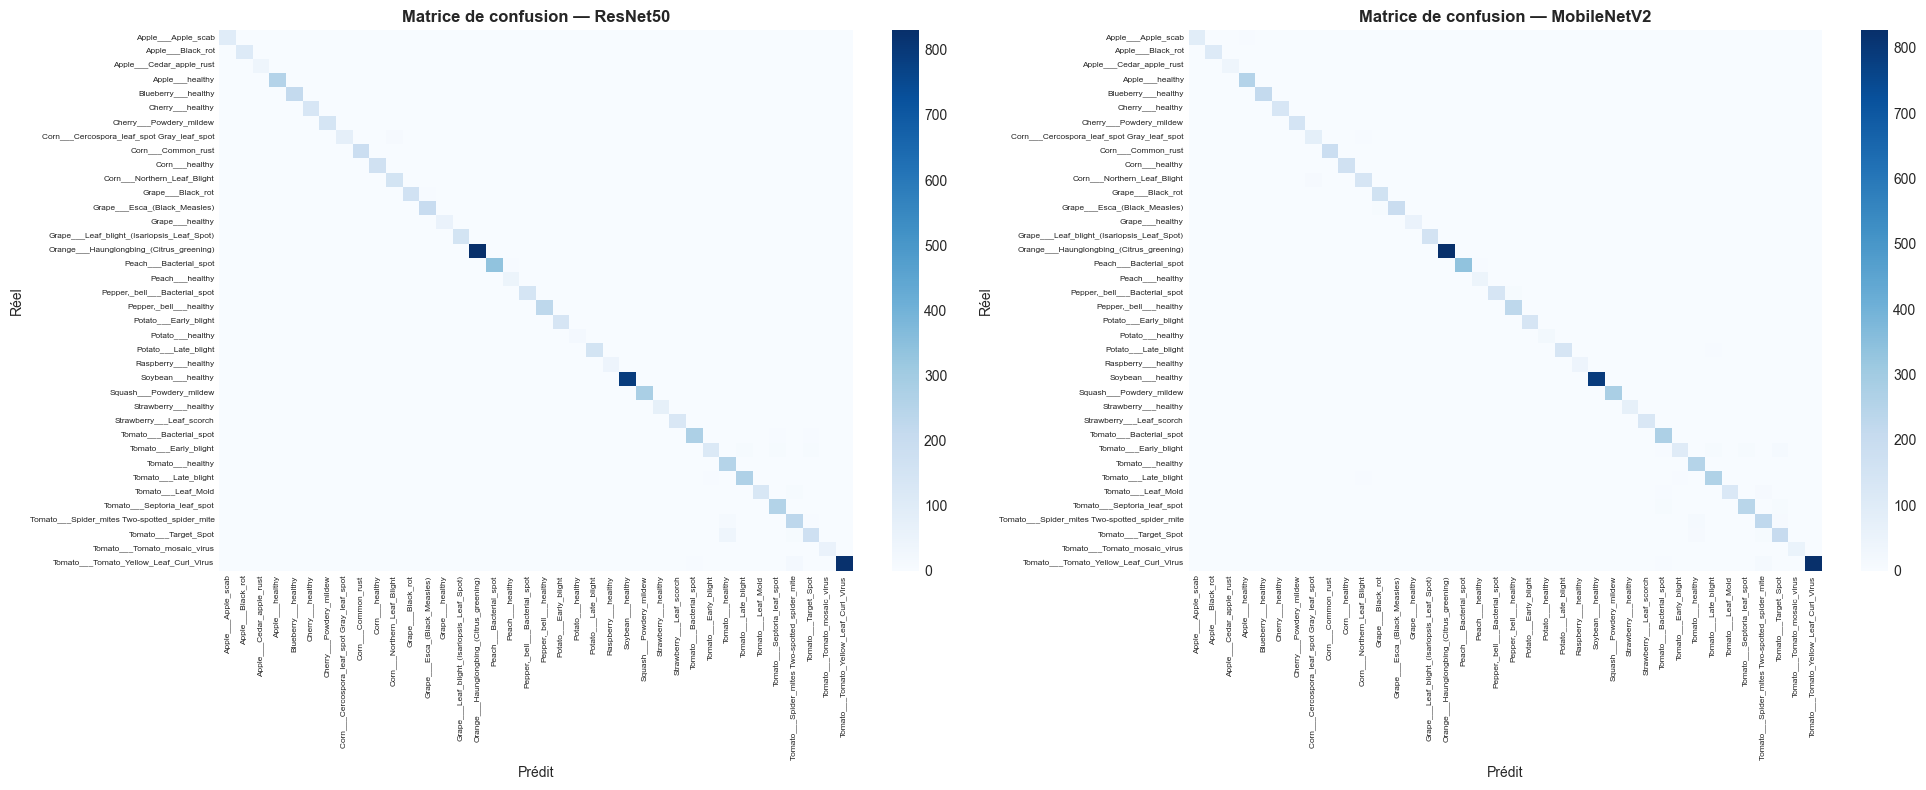


     COMPARAISON FINALE — RÉSULTATS SUR LE JEU DE TEST


,Modèle,Test Accuracy,Test Loss,F1-score,Paramètres
0,ResNet50,0.975077,0.093969,0.974993,~25.6M
1,MobileNetV2,0.966974,0.113110,0.966876,~3.4M



Meilleur modèle : ResNet50
  Test Accuracy : 0.9751
  F1-score      : 0.9750


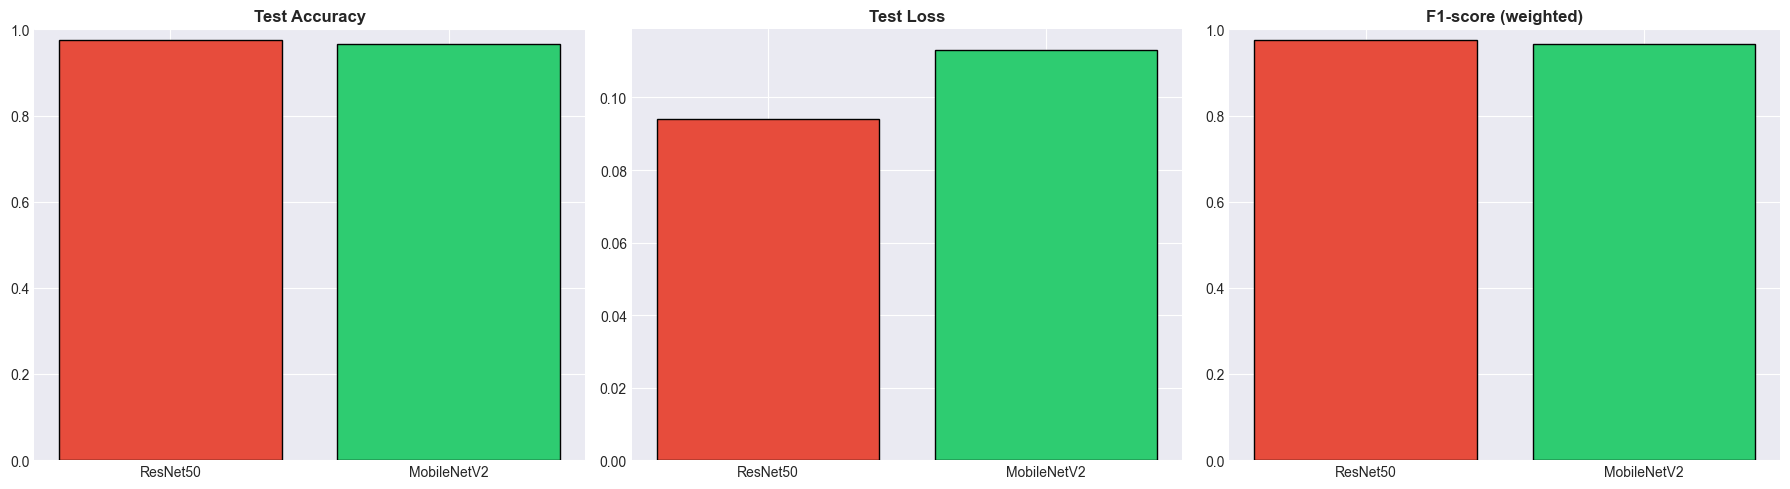

In [31]:
# Matrices de confusion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

cm_resnet = confusion_matrix(y_true_r, y_pred_r)
sns.heatmap(cm_resnet, annot=False, cmap='Blues', ax=ax1,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title('Matrice de confusion — ResNet50', fontweight='bold')
ax1.set_xlabel('Prédit')
ax1.set_ylabel('Réel')
ax1.tick_params(axis='x', rotation=90, labelsize=6)
ax1.tick_params(axis='y', rotation=0, labelsize=6)

cm_mobile = confusion_matrix(y_true_m, y_pred_m)
sns.heatmap(cm_mobile, annot=False, cmap='Blues', ax=ax2,
            xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Matrice de confusion — MobileNetV2', fontweight='bold')
ax2.set_xlabel('Prédit')
ax2.set_ylabel('Réel')
ax2.tick_params(axis='x', rotation=90, labelsize=6)
ax2.tick_params(axis='y', rotation=0, labelsize=6)

plt.tight_layout()
plt.show()

# Tableau comparatif
results = pd.DataFrame({
    'Modèle': ['ResNet50', 'MobileNetV2'],
    'Test Accuracy': [test_acc_r, test_acc_m],
    'Test Loss': [test_loss_r, test_loss_m],
    'F1-score': [f1_r, f1_m],
    'Paramètres': ['~25.6M', '~3.4M']
})
results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "=" * 65)
print("     COMPARAISON FINALE — RÉSULTATS SUR LE JEU DE TEST")
print("=" * 65)
display(results)

best = results.iloc[0]
print(f"\nMeilleur modèle : {best['Modèle']}")
print(f"  Test Accuracy : {best['Test Accuracy']:.4f}")
print(f"  F1-score      : {best['F1-score']:.4f}")

# Barplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#e74c3c', '#2ecc71']

ax1.bar(results['Modèle'], results['Test Accuracy'], color=colors, edgecolor='black')
ax1.set_title('Test Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1)

ax2.bar(results['Modèle'], results['Test Loss'], color=colors, edgecolor='black')
ax2.set_title('Test Loss', fontsize=12, fontweight='bold')

ax3.bar(results['Modèle'], results['F1-score'], color=colors, edgecolor='black')
ax3.set_title('F1-score (weighted)', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

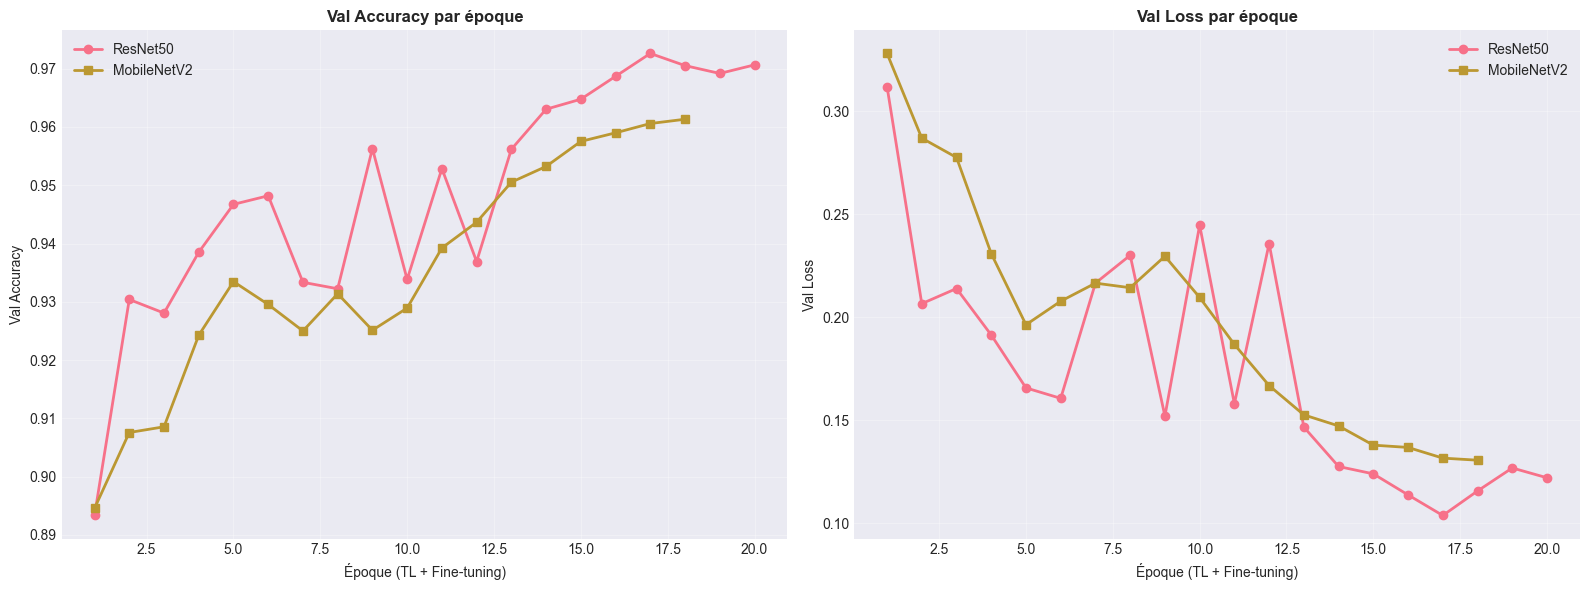

In [32]:
# --- Comparaison des courbes d'entraînement ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

r_acc = history_resnet_tl.history['val_accuracy'] + history_resnet_ft.history['val_accuracy']
r_loss = history_resnet_tl.history['val_loss'] + history_resnet_ft.history['val_loss']
m_acc = history_mobile_tl.history['val_accuracy'] + history_mobile_ft.history['val_accuracy']
m_loss = history_mobile_tl.history['val_loss'] + history_mobile_ft.history['val_loss']

axes[0].plot(range(1, len(r_acc)+1), r_acc, label='ResNet50', marker='o', linewidth=2)
axes[0].plot(range(1, len(m_acc)+1), m_acc, label='MobileNetV2', marker='s', linewidth=2)
axes[0].set_title('Val Accuracy par époque', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Époque (TL + Fine-tuning)')
axes[0].set_ylabel('Val Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(r_loss)+1), r_loss, label='ResNet50', marker='o', linewidth=2)
axes[1].plot(range(1, len(m_loss)+1), m_loss, label='MobileNetV2', marker='s', linewidth=2)
axes[1].set_title('Val Loss par époque', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Époque (TL + Fine-tuning)')
axes[1].set_ylabel('Val Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8) Sauvegarde du meilleur modèle

On sauvegarde le modèle avec la meilleure **Test Accuracy**.

In [33]:
# Sauvegarder le meilleur modèle
best_name = results.iloc[0]['Modèle']
best_model = model_mobile if best_name == 'MobileNetV2' else model_resnet
best_acc = results.iloc[0]['Test Accuracy']
best_f1 = results.iloc[0]['F1-score']

model_save_path = os.path.join('..', 'models', f'{best_name.lower()}_plant_disease.keras')
best_model.save(model_save_path)

print(f"[OK] Meilleur modèle sauvegardé : {model_save_path}")
print(f"  Modèle       : {best_name} (Transfer Learning + Fine-tuning)")
print(f"  Test Accuracy : {best_acc:.4f}")
print(f"  F1-score      : {best_f1:.4f}")

[OK] Meilleur modèle sauvegardé : ../../models/resnet50_plant_disease.keras
  Modèle       : ResNet50 (Transfer Learning + Fine-tuning)
  Test Accuracy : 0.9751
  F1-score      : 0.9750


## Conclusion

| Modèle | Architecture | Paramètres | Approche |
|---|---|---|---|
| **ResNet50** | 50 couches, residual blocks | ~25.6M | Transfer Learning + Fine-tuning |
| **MobileNetV2** | Depthwise separable convolutions | ~3.4M | Transfer Learning + Fine-tuning |

**Protocole d'évaluation** :
- Split 70/15/15 (train / validation / test)
- Images 224×224, `preprocess_input` spécifique à chaque modèle
- Labels entiers → `sparse_categorical_crossentropy`
- Early Stopping (patience=3, restore_best_weights)
- Évaluation finale sur le **jeu de test** (accuracy, precision, recall, F1, matrice de confusion)

**Justification du choix de MobileNetV2** :
1. **Performance comparable** à ResNet50 avec **7× moins de paramètres**
2. Architecture optimisée pour le **déploiement mobile/embarqué** — idéal pour l'agriculture de terrain
3. Le **transfer learning** exploite les features visuelles pré-apprises sur ImageNet
4. Le **fine-tuning** adapte les dernières couches aux spécificités des feuilles malades
5. Convergence **plus rapide** et meilleure **efficacité computationnelle**